## Example: Generating formal assume-guarantee contracts for an enzymatic system using log-derivative polytopes

### Ayush Pandey
### Date: April 2, 2026

In this example, we consider the standard enzymatic system example. For this system, we use the log-derivative polytopes to generate assume-guarantee contracts under various assumptions.

### Goals: 

* Compute log-derivative polytopes for the enzymatic system under various assumptions (enzyme saturation, substrate saturation, etc.).
* Compute assume-guarantee contracts using Pacti for each of the log-derivative polytopes.
* Validate that the contracts describe the behavior of the system under the corresponding assumptions by verifying against empirical simulations of reduced models.

Plotting settings:

In [9]:

import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

matplotlib.rcParams['text.usetex'] = False  
matplotlib.rcParams['mathtext.fontset'] = 'cm' 

# Font sizes
SMALL_SIZE  = 14
MEDIUM_SIZE = 16
LARGE_SIZE  = 18

matplotlib.rcParams['font.size']        = MEDIUM_SIZE  
matplotlib.rcParams['axes.titlesize']   = LARGE_SIZE   
matplotlib.rcParams['axes.labelsize']   = LARGE_SIZE   
matplotlib.rcParams['xtick.labelsize']  = MEDIUM_SIZE  
matplotlib.rcParams['ytick.labelsize']  = MEDIUM_SIZE 
matplotlib.rcParams['legend.fontsize']  = SMALL_SIZE  
matplotlib.rcParams['figure.titlesize'] = LARGE_SIZE  

# Tick parameters
matplotlib.rcParams['xtick.major.size']  = 7
matplotlib.rcParams['xtick.major.width'] = 1.5
matplotlib.rcParams['ytick.major.size']  = 7
matplotlib.rcParams['ytick.major.width'] = 1.5
matplotlib.rcParams['xtick.minor.size']  = 4
matplotlib.rcParams['xtick.minor.width'] = 1.0
matplotlib.rcParams['ytick.minor.size']  = 4
matplotlib.rcParams['ytick.minor.width'] = 1.0

# Line widths
matplotlib.rcParams['lines.linewidth']  = 2.0
matplotlib.rcParams['axes.linewidth']   = 1.5


In [1]:
### all imports and helpers

import numpy as np
import matplotlib.pyplot as plt

from pacti.contracts import PolyhedralIoContract
from pacti.iocontract import Var
from pacti.utils.plots import plot_assumptions, plot_guarantees

# standard enzymatic system: E + S <-> C -> E + P
def exact_C(E_tot, S_tot, K):
    """
    Physical root of:
        C = (E_tot - C)(S_tot - C)/K
    """
    disc = (E_tot + S_tot + K) ** 2 - 4.0 * E_tot * S_tot
    return 0.5 * ((E_tot + S_tot + K) - np.sqrt(disc))


def free_ES(E_tot, S_tot, K):
    C = exact_C(E_tot, S_tot, K)
    E = E_tot - C
    S = S_tot - C
    return E, S, C


def exact_H(E_tot, S_tot, K):
    """
    Compute the log-derivative polytope 
    from Xiao et al. ACC 2021
    (d log C / d log E_tot, d log C / d log S_tot)
    """
    E, S, C = free_ES(E_tot, S_tot, K)
    H_E = (K + S) / (K + E + S)
    H_S = (K + E) / (K + E + S)
    return H_E, H_S


def log_vars(E_tot, S_tot, K, kcat):
    C = exact_C(E_tot, S_tot, K)
    z_u = np.log(E_tot)
    z_x = np.log(S_tot) 
    z_C = np.log(C)   
    z_y = np.log(kcat) + z_C 
    return z_u, z_x, z_C, z_y


# helper function
def point_term_dict(vars_to_values):
    """
    Equalities in Pacti can be written as two inequalities. This helper generates those two.
    """
    terms = []
    for name, value in vars_to_values.items():
        terms.append({"coefficients": {name: 1.0}, "constant": float(value)})
        terms.append({"coefficients": {name: -1.0}, "constant": float(-value)})
    return terms


# actual model outputs to be checked against contracts

def mm_flux(E_tot, S_tot, K, kcat):
    return kcat * E_tot * S_tot / (K + S_tot)

def exact_reduced_flux(E_tot, S_tot, K, kcat):
    C = exact_C(E_tot, S_tot, K)
    return kcat * C


In [4]:
# x and y axis grids
E_vals_common = np.logspace(-4, 4, 220)
S_vals_common = np.logspace(-4, 4, 220)
n_y = 260

# parameter values

K = 20.0
kcat = 3.0

zK = np.log(K)
zkcat = np.log(kcat)

# log-separation margins
# example choice: one order of magnitude
delta_Ku = np.log(2.0)
delta_Kx = np.log(2.0)

delta_xu = np.log(2.0)
delta_xK = np.log(2.0)

delta_ux = np.log(2.0)
delta_uK = np.log(2.0)
# the eta parameters from the paper (see equations 11, 12)
eta_11 = np.log(1.0 + np.exp(-delta_Ku) + np.exp(-delta_Kx))
eta_10 = -np.log((1.0 - np.exp(-delta_xu)) / (1.0 + np.exp(-delta_xK)))
eta_01 = -np.log((1.0 - np.exp(-delta_ux)) / (1.0 + np.exp(-delta_uK)))

In [5]:
# create contracts, as derived in the paper
contract_K_dom = {
    "input_vars": ["z_u", "z_x"],
    "output_vars": ["z_C"],
    "assumptions": [
        # z_u <= zK - delta_Ku
        {"coefficients": {"z_u": 1.0}, "constant": zK - delta_Ku},
        # z_x <= zK - delta_Kx
        {"coefficients": {"z_x": 1.0}, "constant": zK - delta_Kx},
    ],
    "guarantees": [
        # z_C <= z_u + z_x - zK
        {"coefficients": {"z_C": 1.0, "z_u": -1.0, "z_x": -1.0}, "constant": -zK},
        # z_u + z_x - z_C <= zK + eta_11
        {"coefficients": {"z_u": 1.0, "z_x": 1.0, "z_C": -1.0}, "constant": zK + eta_11},
    ],
}
# same contract but with z_y as output variable.
contract_Ky = {
    "input_vars": ["z_u", "z_x"],
    "output_vars": ["z_y"],
    "assumptions": [
        {"coefficients": {"z_u": 1.0}, "constant": zK - delta_Ku},
        {"coefficients": {"z_x": 1.0}, "constant": zK - delta_Kx},
    ],
    "guarantees": [
        # z_y <= z_u + z_x - zK + zkcat
        {"coefficients": {"z_y": 1.0, "z_u": -1.0, "z_x": -1.0},
         "constant": zkcat - zK},
        # z_y >= z_u + z_x - zK + zkcat - eta_11
        {"coefficients": {"z_u": 1.0, "z_x": 1.0, "z_y": -1.0},
         "constant": zK - zkcat + eta_11},
    ],
}
contract_S_dom = {
    "input_vars": ["z_u", "z_x"],
    "output_vars": ["z_C"],
    "assumptions": [
        # z_u <= z_x - delta_xu
        {"coefficients": {"z_u": 1.0, "z_x": -1.0}, "constant": -delta_xu},
        # zK <= z_x - delta_xK  <=>  -z_x <= -(zK + delta_xK)
        {"coefficients": {"z_x": -1.0}, "constant": -(zK + delta_xK)},
    ],
    "guarantees": [
        # z_C <= z_u
        {"coefficients": {"z_C": 1.0, "z_u": -1.0}, "constant": 0.0},
        # z_u - z_C <= eta_10
        {"coefficients": {"z_u": 1.0, "z_C": -1.0}, "constant": eta_10},
    ],
}

# same contract but with z_y as output variable.
contract_Sy = {
    "input_vars": ["z_u", "z_x"],
    "output_vars": ["z_y"],
    "assumptions": [
        # z_x - z_u >= delta_xu
        {"coefficients": {"z_u": 1.0, "z_x": -1.0}, "constant": -delta_xu},
        # z_x - zK >= delta_xK
        {"coefficients": {"z_x": -1.0}, "constant": -(zK + delta_xK)},
    ],
    "guarantees": [
        # z_y <= z_u + zkcat
        {"coefficients": {"z_y": 1.0, "z_u": -1.0}, "constant": zkcat},
        # z_y >= z_u + zkcat - eta_10
        {"coefficients": {"z_u": 1.0, "z_y": -1.0}, "constant": eta_10 - zkcat},
    ],
}


contract_E_dom = {
    "input_vars": ["z_u", "z_x"],
    "output_vars": ["z_C"],
    "assumptions": [
        # z_x <= z_u - delta_ux
        {"coefficients": {"z_x": 1.0, "z_u": -1.0}, "constant": -delta_ux},
        # zK <= z_u - delta_uK  <=>  -z_u <= -(zK + delta_uK)
        {"coefficients": {"z_u": -1.0}, "constant": -(zK + delta_uK)},
    ],
    "guarantees": [
        # z_C <= z_x
        {"coefficients": {"z_C": 1.0, "z_x": -1.0}, "constant": 0.0},
        # z_x - z_C <= eta_01
        {"coefficients": {"z_x": 1.0, "z_C": -1.0}, "constant": eta_01},
    ],
}
# same contract but with z_y as output variable.


contract_Ey = {
    "input_vars": ["z_u", "z_x"],
    "output_vars": ["z_y"],
    "assumptions": [
        # z_u - z_x >= delta_ux
        {"coefficients": {"z_x": 1.0, "z_u": -1.0}, "constant": -delta_ux},
        # z_u - zK >= delta_uK
        {"coefficients": {"z_u": -1.0}, "constant": -(zK + delta_uK)},
    ],
    "guarantees": [
        # z_y <= z_x + zkcat
        {"coefficients": {"z_y": 1.0, "z_x": -1.0}, "constant": zkcat},
        # z_y >= z_x + zkcat - eta_01
        {"coefficients": {"z_x": 1.0, "z_y": -1.0}, "constant": eta_01 - zkcat},
    ],
}

c_Ky = PolyhedralIoContract.from_dict(contract_Ky)
c_Sy = PolyhedralIoContract.from_dict(contract_Sy)
c_Ey = PolyhedralIoContract.from_dict(contract_Ey)

c_K = PolyhedralIoContract.from_dict(contract_K_dom)
c_S = PolyhedralIoContract.from_dict(contract_S_dom)
c_E = PolyhedralIoContract.from_dict(contract_E_dom)
print("Contract for K-dominant regime:")
print(c_K)
print("Contract for substrate-dominant regime:")
print(c_S)
print("Contract for enzyme-dominant regime:")
print(c_E)

Contract for K-dominant regime:
InVars: [z_u, z_x]
OutVars:[z_C]
A: [
  z_u <= 2.303
  z_x <= 2.303
]
G: [
  z_C - z_u - z_x <= -2.996
  -z_C + z_u + z_x <= 3.689
]
Contract for substrate-dominant regime:
InVars: [z_u, z_x]
OutVars:[z_C]
A: [
  z_u - z_x <= -0.6931
  -z_x <= -3.689
]
G: [
  z_C - z_u <= 0
  -z_C + z_u <= 1.099
]
Contract for enzyme-dominant regime:
InVars: [z_u, z_x]
OutVars:[z_C]
A: [
  -z_u + z_x <= -0.6931
  -z_u <= -3.689
]
G: [
  z_C - z_x <= 0
  -z_C + z_x <= 1.099
]


Create MM contract (equation 13 in the paper)


In [6]:
zK = np.log(K)
zkcat = np.log(kcat)

delta_mm = np.log(10.0)
zx_lo = np.log(K / 10.0)
zx_hi = np.log(10.0 * K)

def phi_mm(zx, zK):
    return -np.log(1.0 + np.exp(zK - zx))

def dphi_mm(zx, zK):
    return 1.0 / (1.0 + np.exp(zx - zK))

phi_lo = phi_mm(zx_lo, zK)
phi_hi = phi_mm(zx_hi, zK)

m_sec = (phi_hi - phi_lo) / (zx_hi - zx_lo)
b_sec = phi_lo - m_sec * zx_lo

m_tan_lo = dphi_mm(zx_lo, zK)
b_tan_lo = phi_lo - m_tan_lo * zx_lo

m_tan_hi = dphi_mm(zx_hi, zK)
b_tan_hi = phi_hi - m_tan_hi * zx_hi

contract_MM_y = {
    "input_vars": ["z_u", "z_x"],
    "output_vars": ["z_y"],
    "assumptions": [
        # z_x - z_u >= delta_mm
        {"coefficients": {"z_u": 1.0, "z_x": -1.0}, "constant": -delta_mm},
        # z_x >= zx_lo
        {"coefficients": {"z_x": -1.0}, "constant": -zx_lo},
        # z_x <= zx_hi
        {"coefficients": {"z_x": 1.0}, "constant": zx_hi},
    ],
    "guarantees": [
        # lower secant bound:
        # z_y >= z_u + zkcat + m_sec z_x + b_sec
        {"coefficients": {"z_u": 1.0, "z_x": m_sec, "z_y": -1.0},
         "constant": -(zkcat + b_sec)},

        # upper tangent bound at zx_lo:
        # z_y <= z_u + zkcat + m_tan_lo z_x + b_tan_lo
        {"coefficients": {"z_y": 1.0, "z_u": -1.0, "z_x": -m_tan_lo},
         "constant": zkcat + b_tan_lo},

        # upper tangent bound at zx_hi:
        # z_y <= z_u + zkcat + m_tan_hi z_x + b_tan_hi
        {"coefficients": {"z_y": 1.0, "z_u": -1.0, "z_x": -m_tan_hi},
         "constant": zkcat + b_tan_hi},
    ],
}

c_MM_y = PolyhedralIoContract.from_dict(contract_MM_y)
print(c_MM_y)

InVars: [z_u, z_x]
OutVars:[z_y]
A: [
  z_u - z_x <= -2.303
  -z_x <= -0.6931
  z_x <= 5.298
]
G: [
  z_u + 0.5 z_x - z_y <= 1.646
  -z_u - 0.9091 z_x + z_y <= -1.929
  -z_u - 0.09091 z_x + z_y <= 0.5216
]


In [7]:
c_MM_y

<Var InVars: [z_u, z_x]
OutVars:[z_y]
A: [
  z_u - z_x <= -2.303
  -z_x <= -0.6931
  z_x <= 5.298
]
G: [
  z_u + 0.5 z_x - z_y <= 1.646
  -z_u - 0.9091 z_x + z_y <= -1.929
  -z_u - 0.09091 z_x + z_y <= 0.5216
]>

### Sanity check with results from Xiao et al. ACC 2021 (goal \#1)

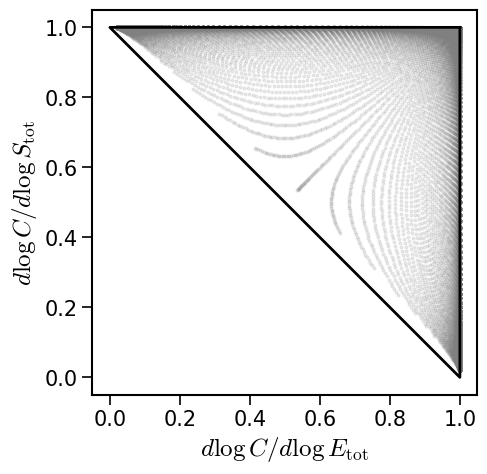

In [10]:
E_tot_vals = np.logspace(-2, 3, 160)
S_tot_vals = np.logspace(-2, 3, 160)

H_pts = []
for E_tot in E_tot_vals:
    for S_tot in S_tot_vals:
        H_pts.append(exact_H(E_tot, S_tot, K))
H_pts = np.array(H_pts)

plt.figure(figsize=(5, 5))
plt.scatter(H_pts[:, 0], H_pts[:, 1], s=4, alpha=0.15, color='grey')

tri = np.array([
    [1.0, 1.0],
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
])
plt.plot(tri[:, 0], tri[:, 1], linewidth=2, color='black')

plt.xlabel(r"$d \log C / d \log E_{\mathrm{tot}}$")
plt.ylabel(r"$d \log C / d \log S_{\mathrm{tot}}$")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.gca().set_aspect("equal", adjustable="box")
ax = plt.gca()
ax.tick_params(axis="both", which="major", labelsize=15, length=7, width=1.2)
ax.tick_params(axis="both", which="minor", labelsize=13, length=4, width=1.0)
plt.savefig("xiao_triangle_check.png", bbox_inches='tight')
plt.show()

### Now we start plotting contract guarantees to validate that the contracts are correctly created (goal \#2)

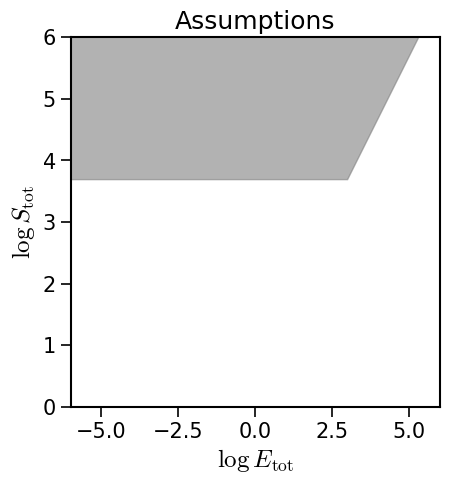

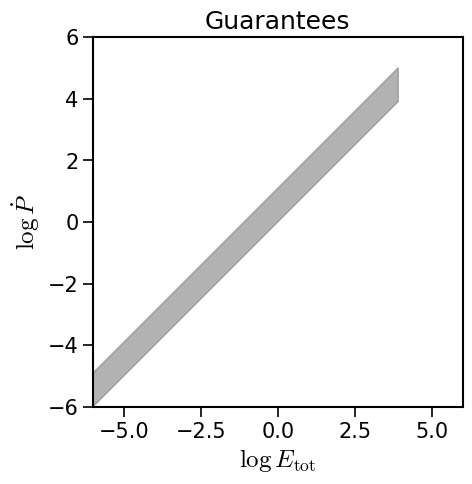

In [11]:
# Block 5: Pacti plots for one regime
# Assumption region and guarantee slab for the substrate-dominant contract
fig = plot_assumptions(
    contract=c_Sy,
    x_var=Var("z_u"),
    y_var=Var("z_x"),
    var_values={Var("z_y"): np.log(0.01)},
    x_lims=(-6, 6),
    y_lims=(0, 6),
)
# Change filled region / patches to light grey
for ax in fig.axes:
    for coll in ax.collections:
        try:
            coll.set_facecolor("grey")
            coll.set_edgecolor("grey")
            coll.set_alpha(0.6)
        except Exception:
            pass

    for patch in ax.patches:
        try:
            patch.set_facecolor("grey")
            patch.set_edgecolor("grey")
            patch.set_alpha(0.6)
        except Exception:
            pass
        
# 
plt.xlabel(r"$\log E_{\mathrm{tot}}$")
plt.ylabel(r"$\log S_{\mathrm{tot}}$")
ax = plt.gca()
ax.tick_params(axis="both", which="major", labelsize=15, length=7, width=1.2)
ax.tick_params(axis="both", which="minor", labelsize=13, length=4, width=1.0)
plt.savefig("substrate_dominant_assumptions.svg", bbox_inches='tight')
plt.show()

# For guarantees, fix z_x and plot the admissible (z_u, z_C) slab.
# Choose a z_x that actually lies in the substrate-dominant region.
z_x_fixed = np.log(100.0)

fig = plot_guarantees(
    contract=c_Sy,
    x_var=Var("z_u"),
    y_var=Var("z_y"),
    var_values={Var("z_x"): z_x_fixed},
    x_lims=(-6, 6),
    y_lims=(-6, 6),
)
# Change filled region / patches to light grey
for ax in fig.axes:
    for coll in ax.collections:
        try:
            coll.set_facecolor("grey")
            coll.set_edgecolor("grey")
            coll.set_alpha(0.6)
        except Exception:
            pass

    for patch in ax.patches:
        try:
            patch.set_facecolor("grey")
            patch.set_edgecolor("grey")
            patch.set_alpha(0.6)
        except Exception:
            pass
        

plt.xlabel(r"$\log E_{\mathrm{tot}}$")
plt.ylabel(r"$\log \dot{P}$")
plt.xlim(-6,6)
plt.ylim(-6,6)

ax = plt.gca()
ax.tick_params(axis="both", which="major", labelsize=15, length=7, width=1.2)
ax.tick_params(axis="both", which="minor", labelsize=13, length=4, width=1.0)
plt.savefig("substrate_dominant_guarantees.svg", bbox_inches='tight')

plt.show()

### Verify model simulation against contract guarantees (goal \#3)

We use Pacti API method: `contains_behavior` on assumptions and guarantees for this.

In [12]:
# Block 3: pure Pacti pointwise verification over a sampled domain
# Uses only contains_behavior on assumptions and guarantees.

from pacti.iocontract import Var

def verify_contract_against_model(contract, model_flux_fn, E_vals, S_vals, K, kcat):
    n_assumption = 0
    n_guarantee = 0

    failing_points = []

    for E_tot in E_vals:
        for S_tot in S_vals:
            z_u = np.log(E_tot)
            z_x = np.log(S_tot)
            z_y = np.log(model_flux_fn(E_tot, S_tot, K, kcat))

            in_A = contract.a.contains_behavior({
                Var("z_u"): z_u,
                Var("z_x"): z_x,
            })

            if not in_A:
                continue

            n_assumption += 1

            in_G = contract.g.contains_behavior({
                Var("z_u"): z_u,
                Var("z_x"): z_x,
                Var("z_y"): z_y,
            })

            if in_G:
                n_guarantee += 1
            else:
                failing_points.append((E_tot, S_tot))

    return {
        "assumption_hits": n_assumption,
        "guarantee_hits": n_guarantee,
        "all_satisfied": (n_assumption == n_guarantee),
        "n_fail": len(failing_points),
        "first_fails": failing_points[:10],
    }

In [13]:
# run verification
E_vals = np.logspace(-4, 4, 220)
S_vals = np.logspace(-4, 4, 220)

print("K-dominant vertex vs exact reduced model:")
print(verify_contract_against_model(c_Ky, exact_reduced_flux, E_vals, S_vals, K, kcat))

print("\nSubstrate-saturated vertex vs exact reduced model:")
print(verify_contract_against_model(c_Sy, exact_reduced_flux, E_vals, S_vals, K, kcat))

print("\nEnzyme-saturated vertex vs exact reduced model:")
print(verify_contract_against_model(c_Ey, exact_reduced_flux, E_vals, S_vals, K, kcat))

print("\nMichaelis-Menten edge vs MM law:")
print(verify_contract_against_model(c_MM_y, mm_flux, E_vals, S_vals, K, kcat))

K-dominant vertex vs exact reduced model:
{'assumption_hits': 18769, 'guarantee_hits': 18769, 'all_satisfied': True, 'n_fail': 0, 'first_fails': []}

Substrate-saturated vertex vs exact reduced model:
{'assumption_hits': 11781, 'guarantee_hits': 11781, 'all_satisfied': True, 'n_fail': 0, 'first_fails': []}

Enzyme-saturated vertex vs exact reduced model:
{'assumption_hits': 11781, 'guarantee_hits': 11781, 'all_satisfied': True, 'n_fail': 0, 'first_fails': []}

Michaelis-Menten edge vs MM law:
{'assumption_hits': 6490, 'guarantee_hits': 6490, 'all_satisfied': True, 'n_fail': 0, 'first_fails': []}


### Finally, run empirical simulations of the exact reduced model and check that they satisfy the contract guarantees (goal \#3)

Substrate saturation contract

Assumptions:
[
  z_u - z_x <= -0.6931
  -z_x <= -3.689
]
Guarantees:
[
  -z_u + z_y <= 1.099
  z_u - z_y <= 0
]
S_fixed = 0.5 K
  points with (u_theta, x_theta) in A_S: 0
  of those, points satisfying guarantees: 0
S_fixed = 1 K
  points with (u_theta, x_theta) in A_S: 0
  of those, points satisfying guarantees: 0
S_fixed = 2 K
  points with (u_theta, x_theta) in A_S: 69
  of those, points satisfying guarantees: 69
S_fixed = 4 K
  points with (u_theta, x_theta) in A_S: 73
  of those, points satisfying guarantees: 73
S_fixed = 16 K
  points with (u_theta, x_theta) in A_S: 80
  of those, points satisfying guarantees: 80
S_fixed = 50 K
  points with (u_theta, x_theta) in A_S: 80
  of those, points satisfying guarantees: 80


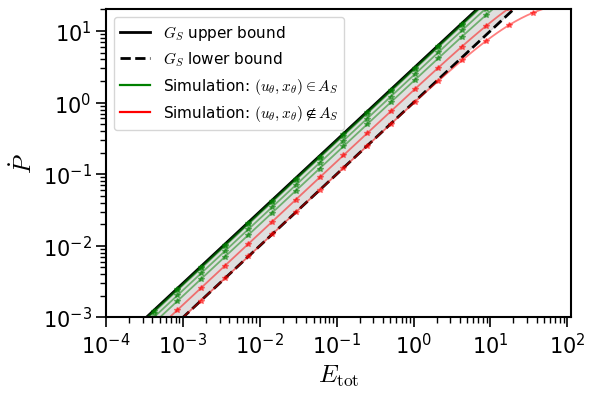

In [ ]:
print("Assumptions:")
print(c_Sy.a)
print("Guarantees:")
print(c_Sy.g)


E_plot_vals = np.logspace(-4, np.log10(50.0 * K / 8.0), 80)

# fixed substrate-total choices = model instances
S_fixed_list = K * np.array([0.5, 1.0, 2.0, 4.0, 16.0, 50.0])
markers = ["*"]*len(S_fixed_list)
figsize = (6, 4)
fill_alpha = 0.25
lower_label = r"$G_S$ lower bound"
upper_label = r"$G_S$ upper bound"
xlabel = r"$E_{\mathrm{tot}}$"
ylabel = r"$\dot{P}$"
# -----------------------------

# contract slab:
#   z_y <= z_u + zkcat
#   z_y >= z_u + zkcat - eta_10
y_lower = np.exp(np.log(E_plot_vals) + np.log(kcat) - eta_10)
y_upper = np.exp(np.log(E_plot_vals) + np.log(kcat))

def in_A_S(u_val, x_val):
    return c_Sy.a.contains_behavior({
        Var("z_u"): np.log(u_val),
        Var("z_x"): np.log(x_val),
    })

def in_G_S(u_val, x_val, y_val):
    return c_Sy.g.contains_behavior({
        Var("z_u"): np.log(u_val),
        Var("z_x"): np.log(x_val),
        Var("z_y"): np.log(y_val),
    })

def plot_masked_curve(xvals, yvals, mask, color, lw=1.3, alpha=0.5):
    start = None
    for i, m in enumerate(mask):
        if m and start is None:
            start = i
        if start is not None and ((not m) or (i == len(mask) - 1)):
            end = i if (not m) else i + 1
            plt.plot(xvals[start:end], yvals[start:end], color=color, linewidth=lw, alpha=alpha, 
                     marker=markers[i % len(markers)], markevery=max(1, len(E_plot_vals) // 20),ms=4,)
            start = None

plt.figure(figsize=figsize)
plt.fill_between(E_plot_vals, y_lower, y_upper, alpha=fill_alpha, color="grey")
plt.plot(E_plot_vals, y_upper, linewidth=2, label=upper_label, color="black", linestyle="-")
plt.plot(E_plot_vals, y_lower, linewidth=2, label=lower_label, color="black", linestyle="--")

for S_fixed in S_fixed_list:
    y_exact = np.array([exact_reduced_flux(e, S_fixed, K, kcat) for e in E_plot_vals])

    inA = np.array([in_A_S(e, S_fixed) for e in E_plot_vals], dtype=bool)
    inG = np.array([in_G_S(e, S_fixed, y) for e, y in zip(E_plot_vals, y_exact)], dtype=bool)

    print(f"S_fixed = {S_fixed/K:.3g} K")
    print("  points with (u_theta, x_theta) in A_S:", int(np.sum(inA)))
    print("  of those, points satisfying guarantees:", int(np.sum(inA & inG)))

    # green where assumptions hold, red where they do not
    plot_masked_curve(E_plot_vals, y_exact, inA, color="green")
    plot_masked_curve(E_plot_vals, y_exact, ~inA, color="red")

plt.plot([], [], color="green", linewidth=1.6, label=r"Simulation: $(u_\theta,x_\theta)\in A_S$")
plt.plot([], [], color="red", linewidth=1.6, label=r"Simulation: $(u_\theta,x_\theta)\notin A_S$")
# plt.plot([], [], color="k", linewidth=1.3, label="reduced models")

plt.xscale("log")
plt.yscale("log")
plt.xlim(E_plot_vals[0], 0.9 * E_plot_vals[-1])
plt.ylim(1e-3, 20)
plt.xlabel(xlabel)
plt.ylabel(ylabel)

ax = plt.gca()
ax.tick_params(axis="both", which="major", labelsize=15, length=7, width=1.2)
ax.tick_params(axis="both", which="minor", labelsize=13, length=4, width=1.0)

plt.legend(fontsize=11)
plt.savefig("substrate_saturated_contract_full_models.svg", bbox_inches="tight")
plt.show()

Enzyme saturated contract

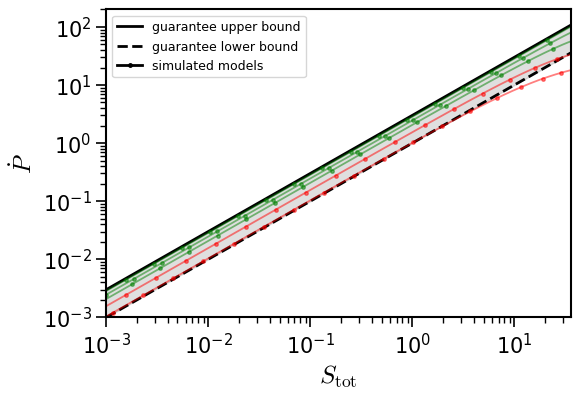

In [16]:

S0_tot = 2.0 * K
kf = 1
kr = kf * K - kcat
E_tot_list = K * np.array([0.5, 1, 2.0, 4, 16])  
colors = ["red", "red", "green", "green", "green"]
x_stop = 1e-4
n_time = 1200
t_final = 40.0 / max(kcat, 1e-12) 

figsize = (6, 4)
fill_alpha = 0.25
lower_label = "guarantee lower bound"
upper_label = "guarantee upper bound"
xlabel = r"$S_{\mathrm{tot}}$"
ylabel = r"$\dot{P}$"
markers = ["o", "o", "o", "o", "o"]

x_grid = np.logspace(np.log10(x_stop), np.log10(S0_tot), 400)
y_lower = np.exp(np.log(x_grid) + np.log(kcat) - eta_01)
y_upper = np.exp(np.log(x_grid) + np.log(kcat))

def full_rhs(t, z):
    E, S, C, P = z
    vf = kf * E * S
    vr = kr * C
    vcat = kcat * C
    dE = -vf + vr + vcat
    dS = -vf + vr
    dC = vf - vr - vcat
    dP = vcat
    return [dE, dS, dC, dP]

def stop_when_x_small(t, z):
    E, S, C, P = z
    return (S + C) - x_stop

stop_when_x_small.terminal = True
stop_when_x_small.direction = -1

def simulate_full_model(E_tot, S_tot0):
    # raw full-model initial condition
    E0 = E_tot
    S0 = S_tot0
    C0 = 0.0
    P0 = 0.0

    sol = solve_ivp(
        full_rhs,
        (0.0, t_final),
        [E0, S0, C0, P0],
        t_eval=np.linspace(0.0, t_final, n_time),
        events=stop_when_x_small,
        method="BDF",
        rtol=1e-8,
        atol=1e-10,
    )

    E, S, C, P = sol.y
    E = np.maximum(E, 0.0)
    S = np.maximum(S, 0.0)
    C = np.maximum(C, 0.0)

    x = S + C
    y = kcat * C

    keep = (x > 0) & (y > 0)
    return x[keep], y[keep]

plt.figure(figsize=figsize)
plt.fill_between(x_grid, y_lower, y_upper, alpha=fill_alpha, color="grey")
plt.plot(x_grid, y_upper, linewidth=2, label=upper_label, color="black", linestyle="-")
plt.plot(x_grid, y_lower, linewidth=2, label=lower_label, color="black", linestyle="--")

for i, E_tot in enumerate(E_tot_list):
    x_traj, y_traj = simulate_full_model(E_tot, S0_tot)

    plt.plot(
        x_traj,
        y_traj,
        marker=markers[i % len(markers)],
        markevery=max(1, len(x_traj) // 20),
        ms=2.5,
        linewidth=1.3,
        alpha=0.5,
        color=colors[i],
        # label=fr"full model, $E_{{\mathrm{{tot}}}}={E_tot/K:.0f}K$"
    )
    if i == 0:
        # add a single label for the whole family
        plt.plot([], [], marker=markers[i % len(markers)], ms=2.5, color="k", label=r"simulated models")

plt.xscale("log")
plt.yscale("log")
plt.xlim(10*x_stop, 0.9*S0_tot)
plt.ylim(1e-3, 200)
plt.xlabel(xlabel)
plt.ylabel(ylabel)

ax = plt.gca()
ax.tick_params(axis="both", which="major", labelsize=15, length=7, width=1.2)
ax.tick_params(axis="both", which="minor", labelsize=13, length=4, width=1.0)

plt.legend(fontsize=9)
plt.savefig("enzyme_saturated_contract_with_full_model.svg", bbox_inches="tight")
plt.show()

Michaelis-Menten contract:

Assumptions:
[
  z_u - z_x <= -2.303
  -z_x <= -0.6931
  z_x <= 5.298
]
Guarantees:
[
  z_u + 0.5 z_x - z_y <= 1.646
  -z_u - 0.9091 z_x + z_y <= -1.929
  -z_u - 0.09091 z_x + z_y <= 0.5216
]


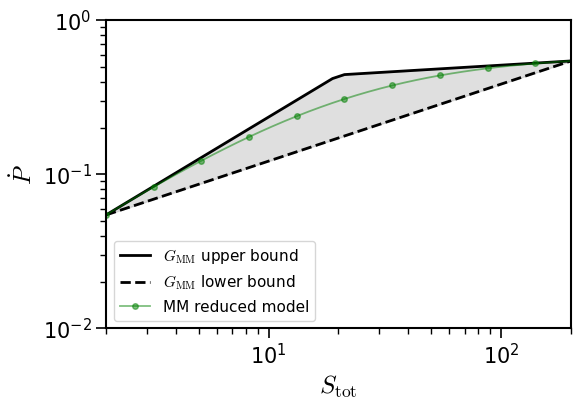

In [17]:

# Contract terms:
#   z_y >= z_u + zkcat + m_sec z_x + b_sec
#   z_y <= z_u + zkcat + m_tan_lo z_x + b_tan_lo
#   z_y <= z_u + zkcat + m_tan_hi z_x + b_tan_hi

print("Assumptions:")
print(c_MM_y.a)
print("Guarantees:")
print(c_MM_y.g)


E_fixed = K / 100.0
S_plot_vals = np.logspace(np.log10(np.exp(zx_lo)), np.log10(np.exp(zx_hi)), 40)

figsize = (6, 4)
fill_alpha = 0.25
lower_label = r"$G_{\mathrm{MM}}$ lower bound"
upper_label = r"$G_{\mathrm{MM}}$ upper bound"
curve_label = r"MM reduced model"
show_exact_reduced_reference = True
title = "Michaelis-Menten edge contract"
xlabel = r"$S_{\mathrm{tot}}$"
ylabel = r"$\dot{P}$"

z_u_fixed = np.log(E_fixed)
z_x_vals = np.log(S_plot_vals)

z_y_lower = z_u_fixed + np.log(kcat) + m_sec * z_x_vals + b_sec
z_y_upper_1 = z_u_fixed + np.log(kcat) + m_tan_lo * z_x_vals + b_tan_lo
z_y_upper_2 = z_u_fixed + np.log(kcat) + m_tan_hi * z_x_vals + b_tan_hi
z_y_upper = np.minimum(z_y_upper_1, z_y_upper_2)

y_lower = np.exp(z_y_lower)
y_upper = np.exp(z_y_upper)

y_mm = np.array([mm_flux(E_fixed, s, K, kcat) for s in S_plot_vals])

# optional exact reduced-model reference
if show_exact_reduced_reference:
    y_exact = np.array([exact_reduced_flux(E_fixed, s, K, kcat) for s in S_plot_vals])

# Pacti verification only along the MM law curve
ok = []
for s, y in zip(S_plot_vals, y_mm):
    z_u = np.log(E_fixed)
    z_x = np.log(s)
    z_y = np.log(y)

    in_A = c_MM_y.a.contains_behavior({Var("z_u"): z_u, Var("z_x"): z_x})
    in_G = c_MM_y.g.contains_behavior({Var("z_u"): z_u, Var("z_x"): z_x, Var("z_y"): z_y})
    ok.append((in_A, in_G))

ok = np.array(ok, dtype=object)
n_assumption = sum(a for a, g in ok)
n_guarantee = sum((a and g) for a, g in ok)


plt.figure(figsize=figsize)
plt.fill_between(S_plot_vals, y_lower, y_upper, alpha=fill_alpha, color="grey")
plt.plot(S_plot_vals, y_upper, linewidth=2, label=upper_label, color="black", linestyle="-")
plt.plot(S_plot_vals, y_lower, linewidth=2, label=lower_label, color="black", linestyle="--")
plt.plot(S_plot_vals, y_mm, marker=markers[i % len(markers)],
        markevery=max(1, len(x_traj) // 100),
        linewidth=1.3,
        alpha=0.5, ms = 4, color="green",
        label=curve_label)

plt.xscale("log")
plt.yscale("log")
plt.xlim(S_plot_vals[0], S_plot_vals[-1])
plt.ylim(1e-2, 1)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
# plt.title(title)

ax = plt.gca()
ax.tick_params(axis="both", which="major", labelsize=15, length=7, width=1.2)
ax.tick_params(axis="both", which="minor", labelsize=13, length=4, width=1.0)
plt.legend(fontsize=11)
plt.savefig("mm_contract.svg", bbox_inches='tight')
plt.show()